Saving company-sales.csv to company-sales (1).csv
Dataset Preview
   month_number  facecream  facewash  toothpaste  bathingsoap  shampoo  \
0             1       2500      1500        5200         9200     1200   
1             2       2630      1200        5100         6100     2100   
2             3       2140      1340        4550         9550     3550   
3             4       3400      1130        5870         8870     1870   
4             5       3600      1740        4560         7760     1560   

   moisturizer  total_units  total_profit  
0         1500        21100        211000  
1         1200        18330        183300  
2         1340        22470        224700  
3         1130        22270        222700  
4         1740        20960        209600  

Dataset Shape: (12, 9)

Cluster Distribution
Consumer_Cluster
2    5
1    4
0    3
Name: count, dtype: int64


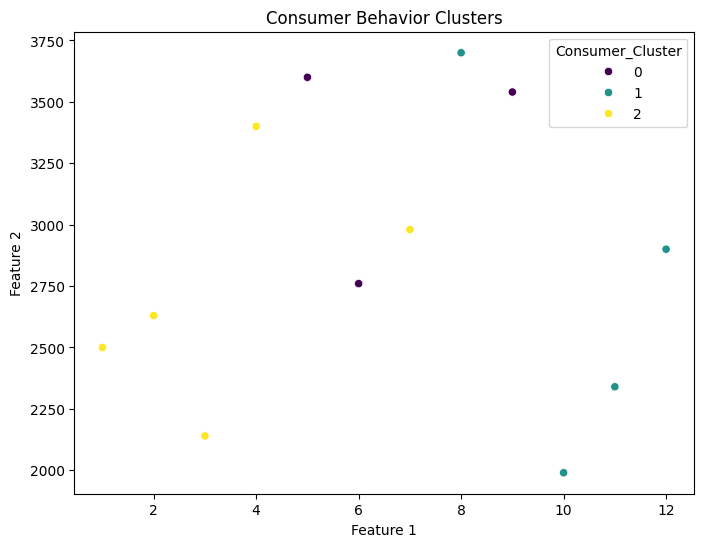


Model Performance
R2 Score: 0.5367084593838911
Mean Squared Error: 3354793910.6666665


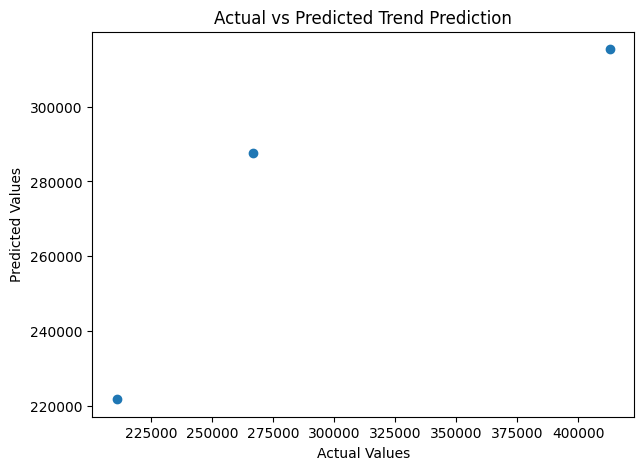

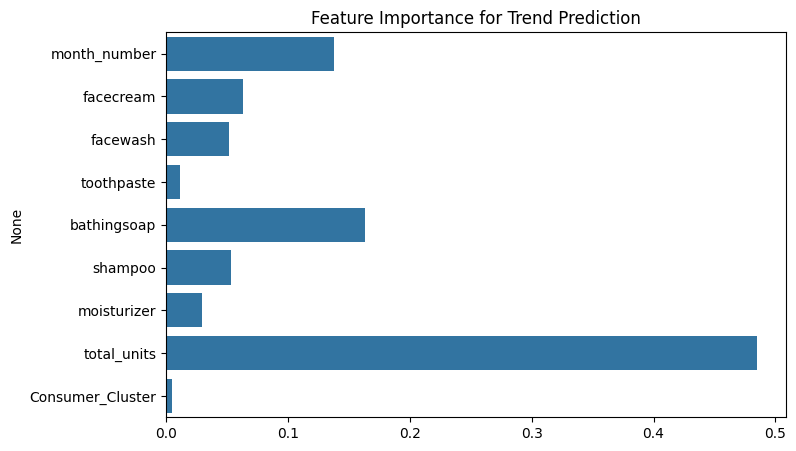

In [2]:
# ============================================
# FMCG TREND PREDICTION - HYBRID ML MODEL
# ============================================

# Step 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# --------------------------------------------
# STEP 1: DATA COLLECTION
# --------------------------------------------

# Upload dataset in Google Colab
from google.colab import files
uploaded = files.upload()

# Read dataset
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Preview")
print(df.head())

print("\nDataset Shape:", df.shape)

# --------------------------------------------
# STEP 2: DATA PREPROCESSING
# --------------------------------------------

# Handle missing values
df = df.dropna()

# Select numeric features
numeric_df = df.select_dtypes(include=np.number)

# Normalize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# --------------------------------------------
# STEP 3: UNSUPERVISED LEARNING (K-MEANS)
# --------------------------------------------

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Consumer_Cluster'] = clusters

print("\nCluster Distribution")
print(df['Consumer_Cluster'].value_counts())

# Visualization of clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=numeric_df.iloc[:,0],
    y=numeric_df.iloc[:,1],
    hue=df['Consumer_Cluster'],
    palette="viridis"
)

plt.title("Consumer Behavior Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# --------------------------------------------
# STEP 4: HYBRID FEATURE INTEGRATION
# --------------------------------------------

# Add cluster as feature
features = df.select_dtypes(include=np.number)

# Target variable (trend indicator / sales)
target_column = features.columns[-2]

X = features.drop(columns=[target_column])
y = features[target_column]

# --------------------------------------------
# STEP 5: SUPERVISED LEARNING (RANDOM FOREST)
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# --------------------------------------------
# STEP 6: MODEL EVALUATION
# --------------------------------------------

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("\nModel Performance")
print("R2 Score:", r2)
print("Mean Squared Error:", mse)

# --------------------------------------------
# STEP 7: ACTUAL VS PREDICTED GRAPH
# --------------------------------------------

plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Trend Prediction")

plt.show()

# --------------------------------------------
# STEP 8: FEATURE IMPORTANCE
# --------------------------------------------

importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=feature_names)

plt.title("Feature Importance for Trend Prediction")
plt.show()